<a href="https://colab.research.google.com/github/HashinieMadhushika/Virtual_Classroom_Engagement_Detector/blob/main/notebooks/engagement_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fahadullaha/facial-emotion-recognition-dataset")

print("Path to dataset files:", path)

100%|██████████| 200M/200M [00:01<00:00, 174MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fahadullaha/facial-emotion-recognition-dataset/versions/1


In [31]:
from pathlib import Path
import random
import sys
import subprocess


def ensure_package(import_name, pip_name=None):
    pip_target = pip_name or import_name
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        print(f"Installing missing package: {pip_target}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_target])


# Day 1 required packages
ensure_package("numpy")
ensure_package("pandas")
ensure_package("matplotlib")
ensure_package("PIL", "pillow")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

# -------------------------------
# 1) SET / AUTO-DETECT DATASET ROOT PATH
# -------------------------------
# Ensure 'path' variable from kagglehub download is available
if 'path' not in globals():
    raise NameError("The 'path' variable from kagglehub download is not defined. Please run the kagglehub download cell first.")

DATASET_ROOT = Path(path)

# Fallback to auto-detection only if the kagglehub path does not exist for some reason
# (e.g., if the user manually changed the first cell or ran locally without kagglehub)
if not DATASET_ROOT.exists():
    print(f"KaggleHub path {DATASET_ROOT} not found, attempting auto-detection.")
    DATASET_ROOT = None # Reset for candidate search
    DATASET_CANDIDATES = [
        Path("../facial-emotion-recognition-dataset/archive/processed_data"),
        Path("../facial-emotion-recognition-dataset/archive"),
        Path("../facial-emotion-recognition-dataset"),
        Path("./facial-emotion-recognition-dataset/archive/processed_data"),
        Path("./facial-emotion-recognition-dataset/archive"),
        Path("./facial-emotion-recognition-dataset"),
        Path("../data/facial_emotion_dataset"),
        Path("../data/facial_emotion_recognition"),
        Path("../data"),
        Path("../dataset"),
        Path("../datasets"),
        Path("./data"),
    ]

    for candidate in DATASET_CANDIDATES:
        if candidate.exists():
            DATASET_ROOT = candidate
            break

    if DATASET_ROOT is None:
        # Final fallback, just in case
        DATASET_ROOT = Path("../root/.cache/kagglehub/datasets/fahadullaha/facial-emotion-recognition-dataset/versions/1")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

print(f"Dataset root selected: {DATASET_ROOT.resolve()}")
print("Exists:", DATASET_ROOT.exists())
if not DATASET_ROOT.exists():
    print("Update DATASET_ROOT to your extracted Kaggle dataset path before running Cell 3.")

Dataset root selected: /root/.cache/kagglehub/datasets/fahadullaha/facial-emotion-recognition-dataset/versions/1
Exists: True


In [32]:
# -------------------------------
# 2) SCAN DATASET AND BUILD TABLE
# -------------------------------
if not DATASET_ROOT.exists():
    print("Dataset path not found:", DATASET_ROOT.resolve())
    print("Download/extract the dataset, then set DATASET_ROOT in Cell 2.")
    df = pd.DataFrame(columns=["label", "image_path"])
else:
    records = []

    # Supports both:
    # A) root/class_name/*.jpg
    # B) root/split_name/class_name/*.jpg  (e.g., train/happy/*.jpg)
    for directory in DATASET_ROOT.rglob("*"):
        if not directory.is_dir():
            continue

        image_files = [p for p in directory.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
        if not image_files:
            continue

        label = directory.name
        for img_path in image_files:
            records.append({"label": label, "image_path": str(img_path)})

    df = pd.DataFrame(records)

    if df.empty:
        print("No images found under DATASET_ROOT.")
        print("Check path and folder structure, then rerun Day 1 cells from the top.")
    else:
        print("Total images:", len(df))
        print("Detected labels:", sorted(df["label"].unique().tolist()))

df.head()

Total images: 49779
Detected labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


,label,image_path
0,fear,/root/.cache/kagglehub/datasets/fahadullaha/fa...
1,fear,/root/.cache/kagglehub/datasets/fahadullaha/fa...
2,fear,/root/.cache/kagglehub/datasets/fahadullaha/fa...
3,fear,/root/.cache/kagglehub/datasets/fahadullaha/fa...
4,fear,/root/.cache/kagglehub/datasets/fahadullaha/fa...


,count,percentage
label,,
happy,11398,22.90
neutral,8166,16.40
sad,6535,13.13
fear,5920,11.89
angry,5920,11.89
disgust,5920,11.89
surprise,5920,11.89


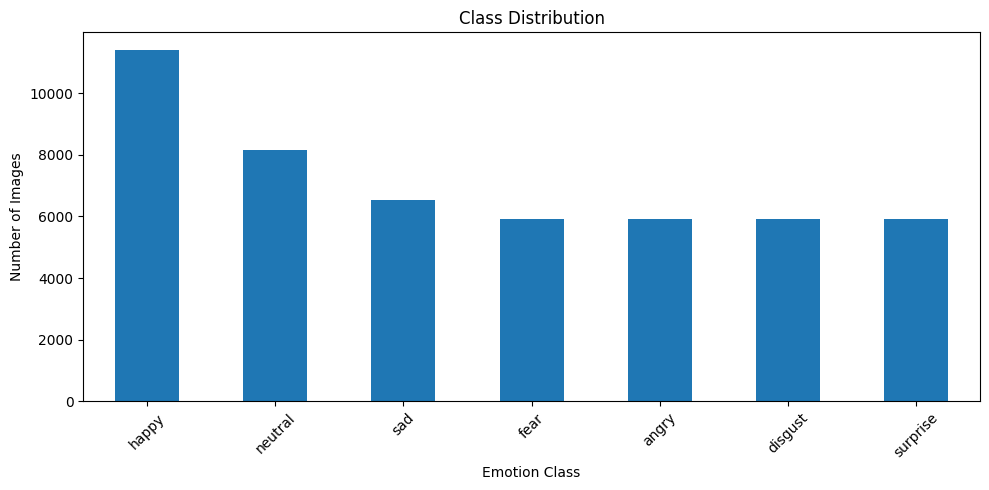

In [33]:
# -------------------------------
# 3) CLASS DISTRIBUTION (IMBALANCE CHECK)
# -------------------------------
if df.empty:
    print("No dataset records available. Run Cell 2 after setting the correct DATASET_ROOT.")
else:
    class_counts = df["label"].value_counts().sort_values(ascending=False)
    class_percent = (class_counts / class_counts.sum() * 100).round(2)

    summary_df = pd.DataFrame({
        "count": class_counts,
        "percentage": class_percent
    })

    display(summary_df)

    plt.figure(figsize=(10, 5))
    class_counts.plot(kind="bar")
    plt.title("Class Distribution")
    plt.xlabel("Emotion Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

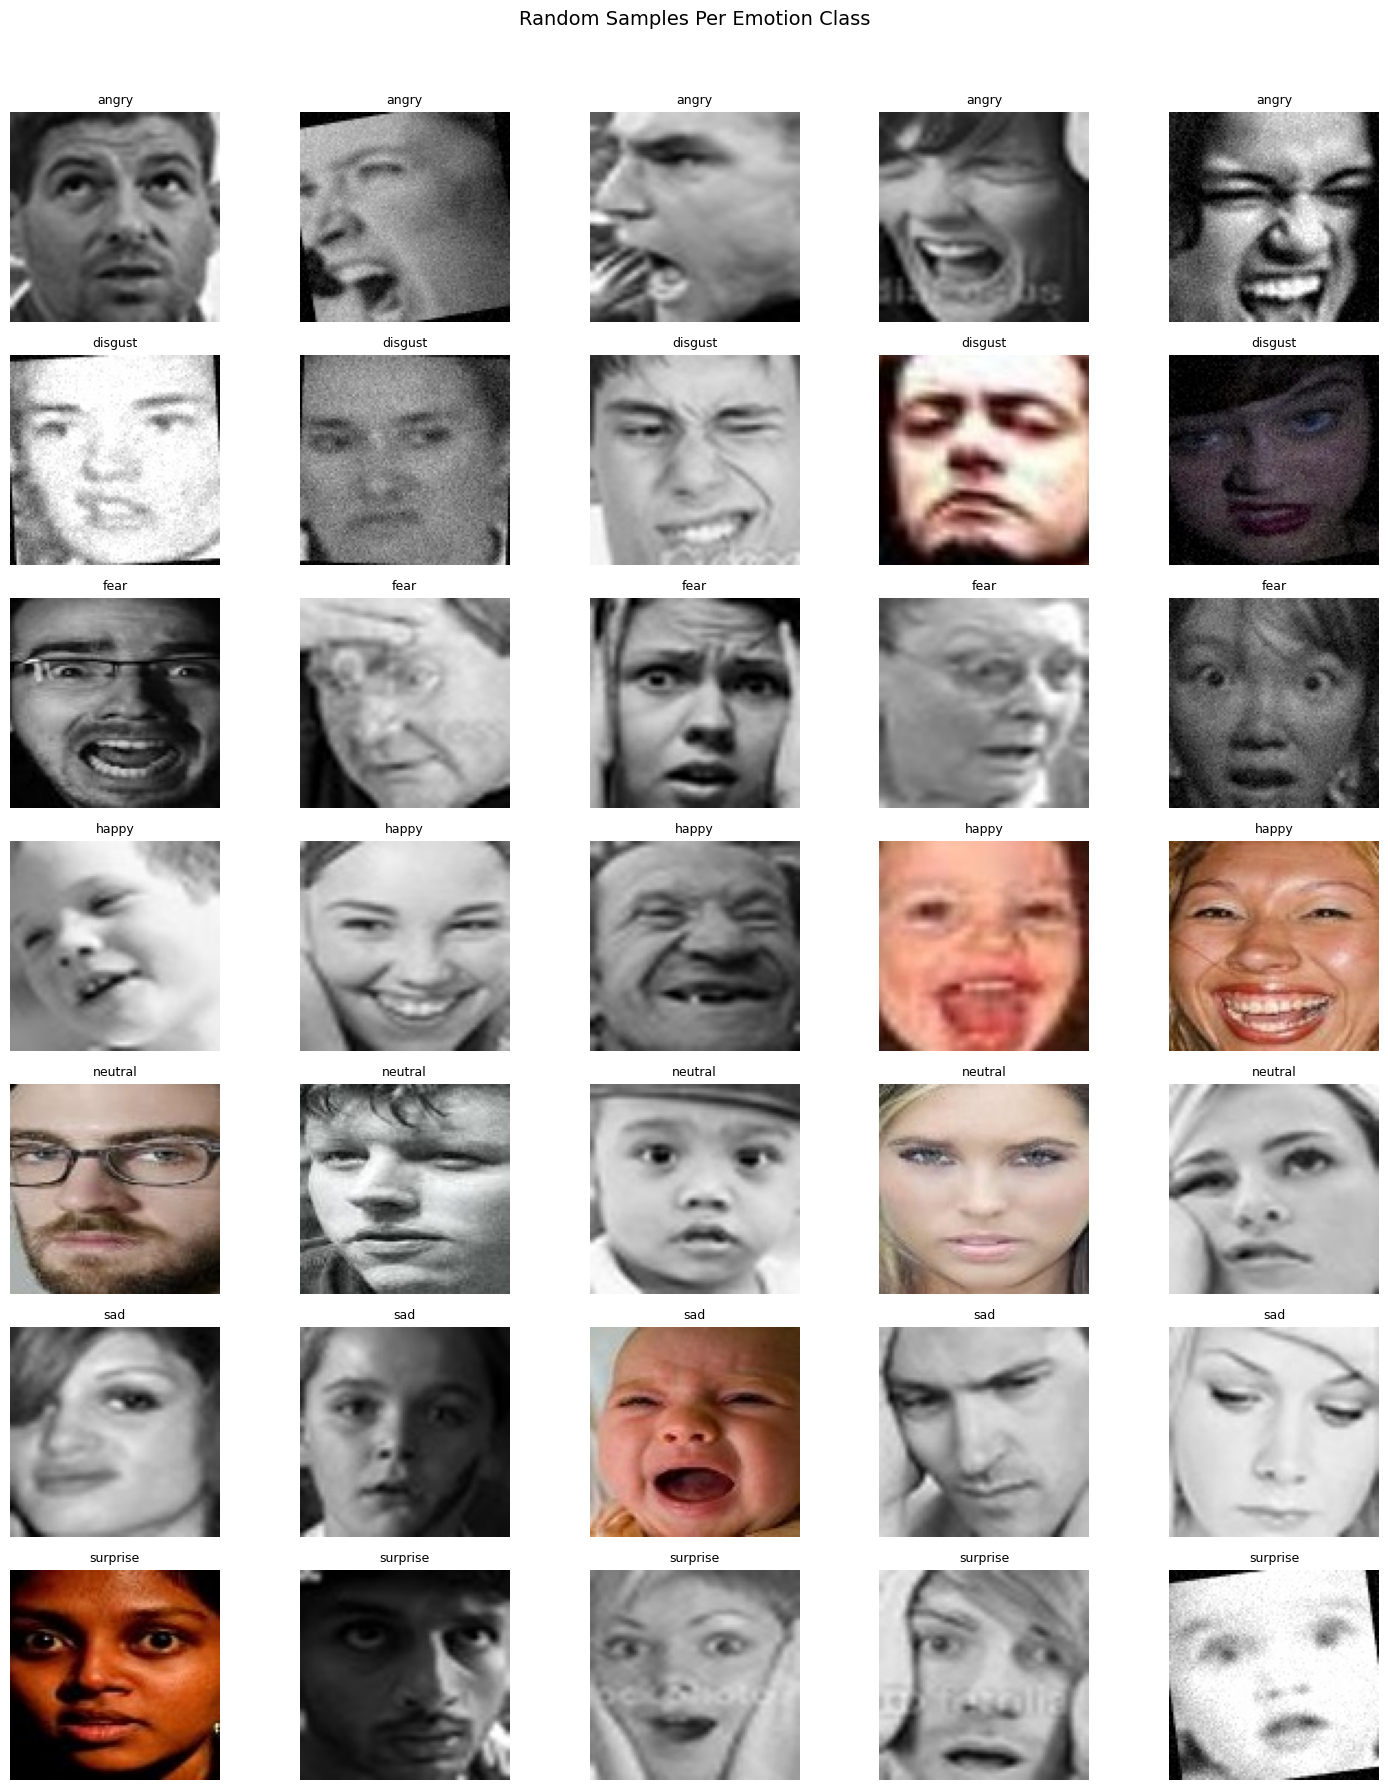

In [34]:
# -------------------------------
# 4) VISUALIZE RANDOM SAMPLES PER CLASS
# -------------------------------
if df.empty:
    print("No dataset records available. Run Cell 2 after setting the correct DATASET_ROOT.")
else:
    SAMPLES_PER_CLASS = 5
    labels = sorted(df["label"].unique())

    fig, axes = plt.subplots(len(labels), SAMPLES_PER_CLASS, figsize=(3 * SAMPLES_PER_CLASS, 2.5 * len(labels)))
    axes = np.array(axes, dtype=object)
    if axes.ndim == 1:
        axes = axes.reshape(1, -1)

    for row_idx, label in enumerate(labels):
        subset = df[df["label"] == label]
        sample_n = min(SAMPLES_PER_CLASS, len(subset))
        sample_rows = subset.sample(n=sample_n, random_state=RANDOM_SEED)

        for col_idx in range(SAMPLES_PER_CLASS):
            ax = axes[row_idx, col_idx]
            ax.axis("off")

            if col_idx < sample_n:
                img_path = sample_rows.iloc[col_idx]["image_path"]
                try:
                    img = Image.open(img_path).convert("RGB")
                    ax.imshow(img)
                    ax.set_title(label, fontsize=9)
                except Exception:
                    ax.text(0.5, 0.5, "Read error", ha="center", va="center", fontsize=8)

    plt.suptitle("Random Samples Per Emotion Class", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

## Day 1 Checklist (Done)

- [ ] Set correct `DATASET_ROOT`
- [ ] Run all cells successfully
- [ ] Save class distribution chart image
- [ ] Save sample grid image
- [ ] Note any severe class imbalance for Day 5 handling

### Output to include in your proposal/report
1. Total number of images
2. List of detected emotion classes
3. Class distribution table + chart
4. Sample images per class (visual proof of labels)

## Day 2: Face Detection + Preprocessing Pipeline

Day 2 objective:
1. Detect faces using HaarCascade
2. Crop and denoise face regions
3. Convert to RGB
4. Resize and save processed images for training
5. Validate outputs with before/after previews

In [35]:
# Day 2 required packages
ensure_package("cv2", "opencv-python")
ensure_package("tqdm")

import cv2
import numpy as np
from tqdm import tqdm

# -------------------------------
# DAY 2 CONFIG
# -------------------------------
PROCESSED_ROOT = Path("../data/processed_faces")
TARGET_SIZE = (64, 64)
MAX_IMAGES_PER_CLASS = None  # Set e.g. 500 for quick testing

haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_path)

if face_cascade.empty():
    raise RuntimeError(f"Could not load HaarCascade from: {haar_path}")

PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
print("Processed output folder:", PROCESSED_ROOT.resolve())
print("HaarCascade:", haar_path)

Processed output folder: /data/processed_faces
HaarCascade: /usr/local/lib/python3.12/dist-packages/cv2/data/haarcascade_frontalface_default.xml


In [36]:
def detect_largest_face_bgr(image_bgr, cascade):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    faces = cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        return None

    x, y, w, h = max(faces, key=lambda box: box[2] * box[3])
    return image_bgr[y:y+h, x:x+w]


def preprocess_face(face_bgr, target_size=(64, 64)):
    denoised = cv2.fastNlMeansDenoisingColored(face_bgr, None, 10, 10, 7, 21)
    rgb = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, target_size, interpolation=cv2.INTER_AREA)
    return resized

In [38]:
# -------------------------------
# PROCESS DATASET IMAGES
# -------------------------------
if "MAX_IMAGES_PER_CLASS" not in globals() or "face_cascade" not in globals():
    raise ValueError("Run Day 2 Cell 8 first (config/imports).")

processed_records = []
skipped_no_face = 0
skipped_read_error = 0

for label in sorted(df["label"].unique()):
    label_df = df[df["label"] == label]
    if MAX_IMAGES_PER_CLASS is not None:
        label_df = label_df.sample(n=min(MAX_IMAGES_PER_CLASS, len(label_df)), random_state=RANDOM_SEED)

    output_label_dir = PROCESSED_ROOT / label
    output_label_dir.mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(label_df.iterrows(), total=len(label_df), desc=f"Processing {label}"):
        src_path = Path(row["image_path"])

        image_bgr = cv2.imread(str(src_path))
        if image_bgr is None:
            skipped_read_error += 1
            continue

        face_bgr = detect_largest_face_bgr(image_bgr, face_cascade)
        if face_bgr is None:
            skipped_no_face += 1
            continue

        processed_rgb = preprocess_face(face_bgr, TARGET_SIZE)

        out_path = output_label_dir / src_path.name
        save_bgr = cv2.cvtColor(processed_rgb, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(out_path), save_bgr)

        processed_records.append({
            "label": label,
            "original_path": str(src_path),
            "processed_path": str(out_path)
        })

processed_df = pd.DataFrame(processed_records)

print("Processed images:", len(processed_df))
print("Skipped (no face):", skipped_no_face)
print("Skipped (read error):", skipped_read_error)
processed_df.head()

Processing surprise: 100%|██████████| 5920/5920 [00:48<00:00, 121.54it/s]

Processed images: 9353
Skipped (no face): 40426
Skipped (read error): 0


,label,original_path,processed_path
0,angry,/root/.cache/kagglehub/datasets/fahadullaha/fa...,../data/processed_faces/angry/angry_03078.jpg
1,angry,/root/.cache/kagglehub/datasets/fahadullaha/fa...,../data/processed_faces/angry/angry_aug00819.jpg
2,angry,/root/.cache/kagglehub/datasets/fahadullaha/fa...,../data/processed_faces/angry/angry_02631.jpg
3,angry,/root/.cache/kagglehub/datasets/fahadullaha/fa...,../data/processed_faces/angry/angry_01339.jpg
4,angry,/root/.cache/kagglehub/datasets/fahadullaha/fa...,../data/processed_faces/angry/angry_01388.jpg


,processed_count
label,
happy,2260
neutral,2037
angry,1173
disgust,1101
sad,1017
fear,976
surprise,789


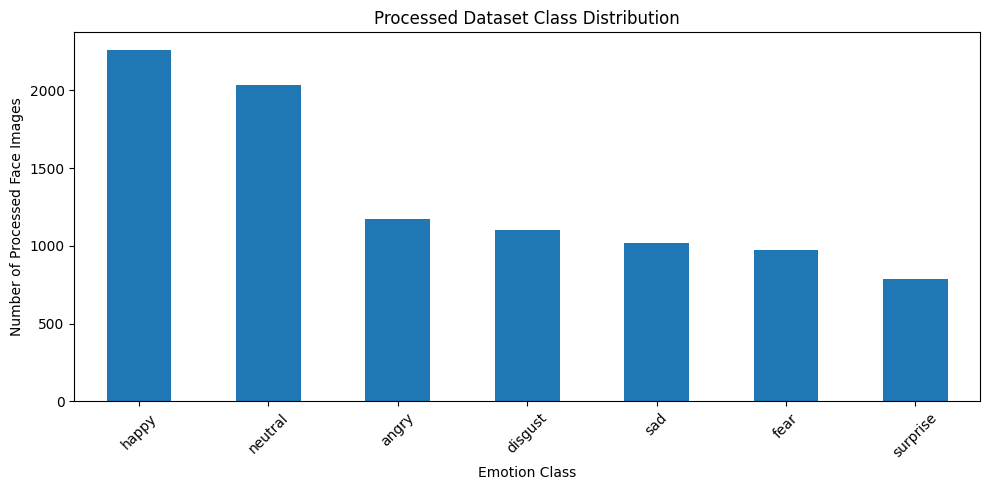

In [39]:
# -------------------------------
# VERIFY PROCESSED DATASET DISTRIBUTION
# -------------------------------
if "processed_df" not in globals() or processed_df.empty:
    print("No processed images found. Run Day 2 Cell 10 first.")
else:
    processed_counts = processed_df["label"].value_counts().sort_values(ascending=False)

    display(processed_counts.to_frame("processed_count"))

    plt.figure(figsize=(10, 5))
    processed_counts.plot(kind="bar")
    plt.title("Processed Dataset Class Distribution")
    plt.xlabel("Emotion Class")
    plt.ylabel("Number of Processed Face Images")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

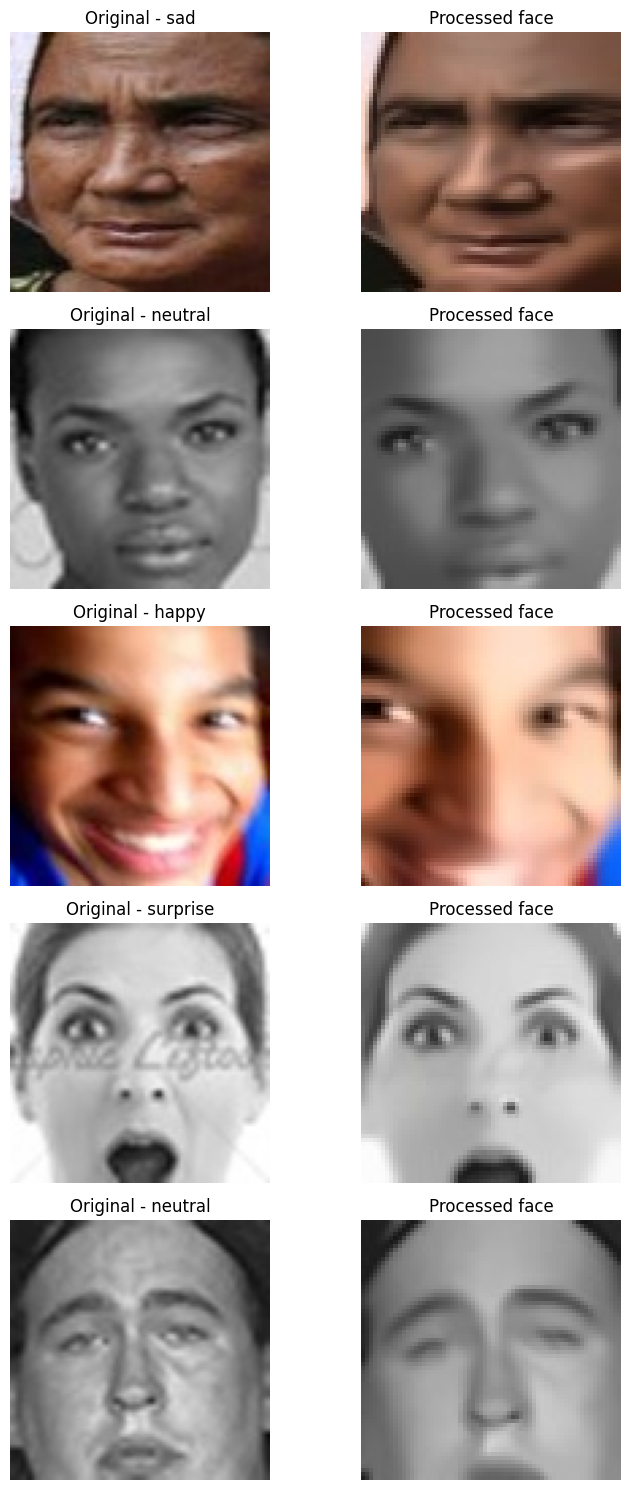

In [40]:
# -------------------------------
# BEFORE/AFTER PREVIEW
# -------------------------------
if "processed_df" not in globals() or processed_df.empty:
    print("No processed images found. Run Day 2 Cell 10 first.")
else:
    PREVIEW_SAMPLES = 5
    preview_rows = processed_df.sample(n=min(PREVIEW_SAMPLES, len(processed_df)), random_state=RANDOM_SEED)

    fig, axes = plt.subplots(len(preview_rows), 2, figsize=(8, 3 * len(preview_rows)))
    axes = np.array(axes, dtype=object)
    if axes.ndim == 1:
        axes = axes.reshape(1, -1)

    for i, (_, row) in enumerate(preview_rows.iterrows()):
        original = Image.open(row["original_path"]).convert("RGB")
        processed = Image.open(row["processed_path"]).convert("RGB")

        axes[i, 0].imshow(original)
        axes[i, 0].set_title(f"Original - {row['label']}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(processed)
        axes[i, 1].set_title("Processed face")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

## Day 2 Checklist

- [ ] Install required packages (`opencv-python`, `tqdm`, `pillow` if missing)
- [ ] Run Day 2 cells end-to-end
- [ ] Confirm processed images are saved under `../data/processed_faces/<label>/`
- [ ] Save one processed distribution chart
- [ ] Save one before/after preview figure

### Day 2 Deliverables for Report
1. Preprocessing pipeline description (HaarCascade + denoise + RGB + resize)
2. Count of successfully processed images
3. Number of skipped images (no face/read error)
4. Visual evidence: before/after samples

## Day 3: Baseline Model (HOG + SVM)

Day 3 objective:
1. Use processed face images from Day 2
2. Extract HOG features
3. Train a supervised baseline model (Linear SVM)
4. Evaluate on validation and test sets using accuracy, macro-F1, and confusion matrix

In [41]:
# Day 3 dependencies
import sys
import subprocess

if "ensure_package" not in globals():
    def ensure_package(import_name, pip_name=None):
        pip_target = pip_name or import_name
        try:
            __import__(import_name)
        except ModuleNotFoundError:
            print(f"Installing missing package: {pip_target}")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pip_target])

ensure_package("sklearn", "scikit-learn")
ensure_package("skimage", "scikit-image")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from skimage.feature import hog

# Rebuild processed_df if notebook kernel was restarted
if "processed_df" not in globals() or processed_df.empty:
    rebuilt_records = []
    for label_dir in sorted([p for p in PROCESSED_ROOT.iterdir() if p.is_dir()]):
        label = label_dir.name
        for img_path in label_dir.rglob("*"):
            if img_path.suffix.lower() in IMAGE_EXTENSIONS:
                rebuilt_records.append({"label": label, "processed_path": str(img_path)})
    processed_df = pd.DataFrame(rebuilt_records)

if processed_df.empty:
    raise ValueError("No processed images found. Run Day 2 first.")

print("Processed images available for Day 3:", len(processed_df))
processed_df.head()

Processed images available for Day 3: 9353


,label,original_path,processed_path
0,angry,/root/.cache/kagglehub/datasets/fahadullaha/fa...,../data/processed_faces/angry/angry_03078.jpg
1,angry,/root/.cache/kagglehub/datasets/fahadullaha/fa...,../data/processed_faces/angry/angry_aug00819.jpg
2,angry,/root/.cache/kagglehub/datasets/fahadullaha/fa...,../data/processed_faces/angry/angry_02631.jpg
3,angry,/root/.cache/kagglehub/datasets/fahadullaha/fa...,../data/processed_faces/angry/angry_01339.jpg
4,angry,/root/.cache/kagglehub/datasets/fahadullaha/fa...,../data/processed_faces/angry/angry_01388.jpg


In [42]:
def extract_hog_from_path(image_path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        return None

    image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    features = hog(
        image_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )
    return features

if "hog" not in globals():
    raise ValueError("Day 3 imports are missing. Run Day 3 Cell 15 first.")

X_features = []
y_labels = []

for _, row in tqdm(processed_df.iterrows(), total=len(processed_df), desc="Extracting HOG"):
    feat = extract_hog_from_path(row["processed_path"])
    if feat is not None:
        X_features.append(feat)
        y_labels.append(row["label"])

X = np.array(X_features)
y = np.array(y_labels)

if len(X) == 0:
    raise ValueError("No features extracted. Check processed image paths.")

print("Feature matrix shape:", X.shape)
print("Label count:", len(y))

Extracting HOG: 100%|██████████| 9353/9353 [00:20<00:00, 462.19it/s]


Feature matrix shape: (9353, 1764)
Label count: 9353


In [43]:
# -------------------------------
# TRAIN / VALIDATION / TEST SPLIT
# -------------------------------
if "X" not in globals() or len(X) == 0:
    raise ValueError("HOG features are missing. Run Day 3 Cell 16 first.")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("Train:", X_train.shape[0], "Val:", X_val.shape[0], "Test:", X_test.shape[0])

# Linear SVM baseline
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, class_weight="balanced", max_iter=5000, random_state=RANDOM_SEED)
)

svm_model.fit(X_train, y_train)
print("Day 3 model training complete.")

Train: 6547 Val: 1403 Test: 1403
Day 3 model training complete.


Validation Accuracy: 0.4127
Validation Macro-F1: 0.3805

Validation Classification Report:
              precision    recall  f1-score   support

       angry       0.30      0.30      0.30       176
     disgust       0.42      0.42      0.42       165
        fear       0.20      0.23      0.22       146
       happy       0.67      0.62      0.64       339
     neutral       0.44      0.41      0.42       306
         sad       0.22      0.26      0.23       152
    surprise       0.43      0.44      0.43       119

    accuracy                           0.41      1403
   macro avg       0.38      0.38      0.38      1403
weighted avg       0.43      0.41      0.42      1403



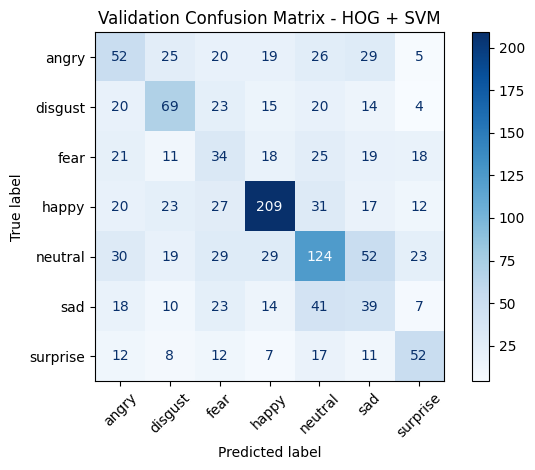

In [44]:
# -------------------------------
# VALIDATION EVALUATION
# -------------------------------
if "svm_model" not in globals():
    raise ValueError("SVM model not found. Run Day 3 Cell 17 first.")

y_val_pred = svm_model.predict(X_val)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1_macro = f1_score(y_val, y_val_pred, average="macro")

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Macro-F1: {val_f1_macro:.4f}")
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)
plt.title("Validation Confusion Matrix - HOG + SVM")
plt.tight_layout()
plt.show()

Test Accuracy: 0.4141
Test Macro-F1: 0.3810

Test Classification Report:
              precision    recall  f1-score   support

       angry       0.32      0.35      0.33       176
     disgust       0.44      0.43      0.43       165
        fear       0.21      0.24      0.22       147
       happy       0.64      0.63      0.64       339
     neutral       0.45      0.37      0.41       305
         sad       0.21      0.24      0.23       153
    surprise       0.40      0.41      0.41       118

    accuracy                           0.41      1403
   macro avg       0.38      0.38      0.38      1403
weighted avg       0.42      0.41      0.42      1403



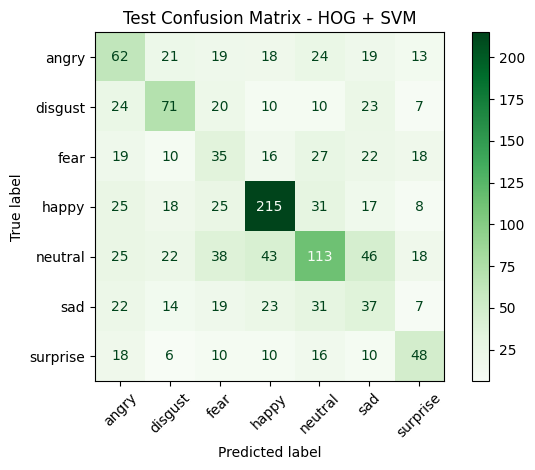

In [45]:
# -------------------------------
# TEST EVALUATION
# -------------------------------
if "svm_model" not in globals():
    raise ValueError("SVM model not found. Run Day 3 Cell 17 first.")

y_test_pred = svm_model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average="macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1_macro:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Greens"
)
plt.title("Test Confusion Matrix - HOG + SVM")
plt.tight_layout()
plt.show()

## Day 3 Checklist

- [ ] Confirm Day 2 processed images exist
- [ ] Run HOG feature extraction successfully
- [ ] Train `LinearSVC` baseline model
- [ ] Record validation accuracy and macro-F1
- [ ] Record test accuracy and macro-F1
- [ ] Save confusion matrix figures

### Day 3 Deliverables for Report
1. Baseline algorithm: HOG + Linear SVM
2. Split strategy: Train/Val/Test = 70/15/15 (stratified)
3. Validation metrics and test metrics
4. Confusion matrix analysis (which emotions are confused most)

## Day 4: Random Forest Classifier (Algorithm 02)

Day 4 objective:
1. Use the same HOG features from Day 3
2. Train a Random Forest classifier
3. Evaluate on validation and test sets
4. Compare with Day 3 SVM baseline

In [46]:
# Day 4 dependencies (Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# Ensure Day 3 feature arrays exist
required_vars = ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test", "label_encoder"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(
        "Day 3 outputs are missing: " + ", ".join(missing) +
        "\nRun Day 3 cells first (HOG extraction + split)."
    )

print("Day 4 will train Random Forest on Day 3 HOG features.")
print("Train shape:", X_train.shape, "Val shape:", X_val.shape, "Test shape:", X_test.shape)

Day 4 will train Random Forest on Day 3 HOG features.
Train shape: (6547, 1764) Val shape: (1403, 1764) Test shape: (1403, 1764)


In [47]:
# -------------------------------
# TRAIN RANDOM FOREST
# -------------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Day 4 Random Forest training complete.")

Day 4 Random Forest training complete.


RF Validation Accuracy: 0.4918
RF Validation Macro-F1: 0.3866

RF Validation Classification Report:
              precision    recall  f1-score   support

       angry       0.56      0.17      0.26       176
     disgust       0.79      0.36      0.49       165
        fear       0.63      0.13      0.22       146
       happy       0.51      0.87      0.65       339
     neutral       0.40      0.77      0.52       306
         sad       0.80      0.05      0.10       152
    surprise       0.67      0.36      0.47       119

    accuracy                           0.49      1403
   macro avg       0.62      0.39      0.39      1403
weighted avg       0.58      0.49      0.43      1403



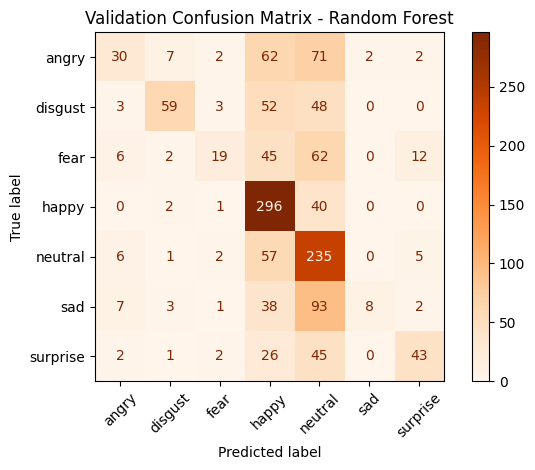

In [48]:
# -------------------------------
# VALIDATION EVALUATION (RANDOM FOREST)
# -------------------------------
y_val_pred_rf = rf_model.predict(X_val)

val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
val_f1_rf = f1_score(y_val, y_val_pred_rf, average="macro")

print(f"RF Validation Accuracy: {val_acc_rf:.4f}")
print(f"RF Validation Macro-F1: {val_f1_rf:.4f}")
print("\nRF Validation Classification Report:")
print(classification_report(y_val, y_val_pred_rf, target_names=label_encoder.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_rf,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Oranges"
)
plt.title("Validation Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

RF Test Accuracy: 0.5053
RF Test Macro-F1: 0.4043

RF Test Classification Report:
              precision    recall  f1-score   support

       angry       0.54      0.14      0.23       176
     disgust       0.86      0.45      0.60       165
        fear       0.65      0.19      0.29       147
       happy       0.53      0.89      0.66       339
     neutral       0.40      0.75      0.52       305
         sad       0.71      0.03      0.06       153
    surprise       0.66      0.36      0.47       118

    accuracy                           0.51      1403
   macro avg       0.62      0.40      0.40      1403
weighted avg       0.58      0.51      0.45      1403



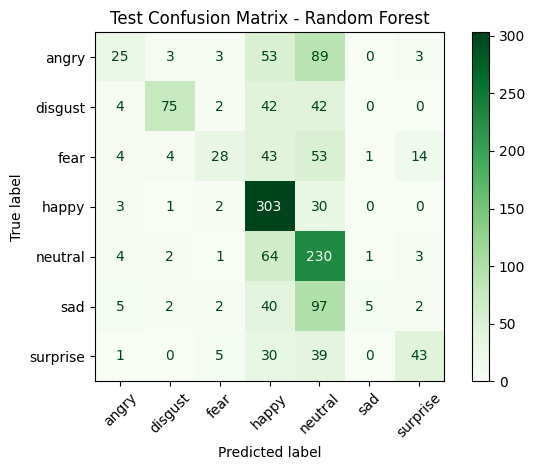

In [49]:
# -------------------------------
# TEST EVALUATION (RANDOM FOREST)
# -------------------------------
y_test_pred_rf = rf_model.predict(X_test)

test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average="macro")

print(f"RF Test Accuracy: {test_acc_rf:.4f}")
print(f"RF Test Macro-F1: {test_f1_rf:.4f}")
print("\nRF Test Classification Report:")
print(classification_report(y_test, y_test_pred_rf, target_names=label_encoder.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_rf,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Greens"
)
plt.title("Test Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

In [50]:
# -------------------------------
# FINAL COMPARISON TABLE (PROPOSAL ALGORITHMS)
# -------------------------------
comparison_rows = [
    {
        "model": "Algorithm_01_SVM",
        "test_accuracy": test_acc if "test_acc" in globals() else np.nan,
        "test_macro_f1": test_f1_macro if "test_f1_macro" in globals() else np.nan
    },
    {
        "model": "Algorithm_02_RandomForest",
        "test_accuracy": test_acc_rf,
        "test_macro_f1": test_f1_rf
    }
]

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

best_row = comparison_df.sort_values(by="test_macro_f1", ascending=False).iloc[0]
print("Best model by macro-F1:", best_row["model"])

,model,test_accuracy,test_macro_f1
0,Algorithm_01_SVM,0.414113,0.381031
1,Algorithm_02_RandomForest,0.505346,0.404348


Best model by macro-F1: Algorithm_02_RandomForest


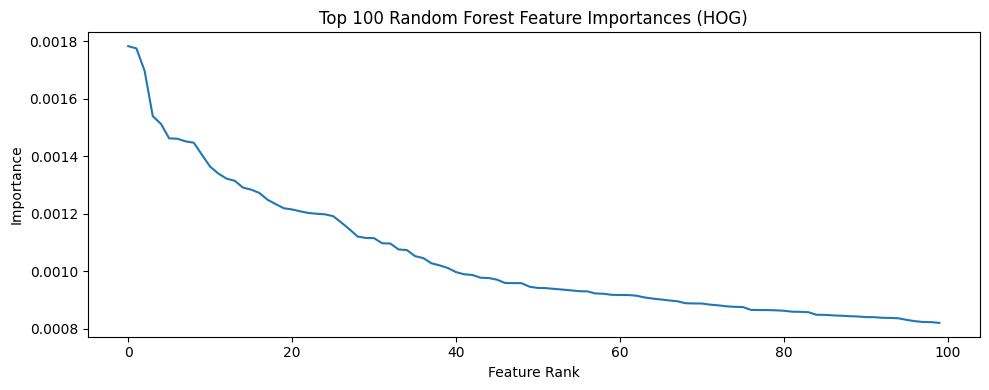

Mean feature importance: 0.0005668934240362812
Max feature importance: 0.0017836386680488531


In [51]:
# -------------------------------
# OPTIONAL: FEATURE IMPORTANCE (RF INTERPRETABILITY)
# -------------------------------
importances = rf_model.feature_importances_

plt.figure(figsize=(10, 4))
plt.plot(np.sort(importances)[::-1][:100])
plt.title("Top 100 Random Forest Feature Importances (HOG)")
plt.xlabel("Feature Rank")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("Mean feature importance:", float(np.mean(importances)))
print("Max feature importance:", float(np.max(importances)))

## Day 4 Checklist (Algorithm 02)

- [ ] Run Day 3 cells first (to generate HOG feature splits)
- [ ] Train `RandomForestClassifier`
- [ ] Record validation and test metrics (accuracy + macro-F1)
- [ ] Save Random Forest confusion matrix figures
- [ ] Complete final comparison table: SVM vs Random Forest

### Day 4 Deliverables for Report
1. Algorithm 01: Support Vector Machine (SVM)
2. Algorithm 02: Random Forest Classifier
3. Validation/test metrics for both models
4. Final conclusion based on macro-F1 and confusion matrix

## Day 5: Class Imbalance Handling (SVM + Random Forest)

Day 5 objective:
1. Handle class imbalance using **Random Oversampling** on training data only
2. Retrain both proposal algorithms (SVM and Random Forest)
3. Compare baseline vs balanced-training performance on the same test set
4. Report whether imbalance handling improves macro-F1 and minority-class recall

In [52]:
# -------------------------------
# VERIFY REQUIRED VARIABLES
# -------------------------------
required_vars = [
    "X_train", "X_val", "X_test", "y_train", "y_val", "y_test",
    "label_encoder", "test_acc", "test_f1_macro", "test_acc_rf", "test_f1_rf"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(
        "Missing variables from Day 3/Day 4: " + ", ".join(missing) +
        "\nRun Day 3 and Day 4 first."
    )

print("Day 5 will use Random Oversampling on training split only.")
print("Original train class counts:")
train_counts = pd.Series(y_train).value_counts().sort_index()
for idx, count in train_counts.items():
    print(f"{label_encoder.classes_[idx]}: {count}")

Day 5 will use Random Oversampling on training split only.
Original train class counts:
angry: 821
disgust: 771
fear: 683
happy: 1582
neutral: 1426
sad: 712
surprise: 552


In [53]:
# -------------------------------
# RANDOM OVERSAMPLING (TRAIN ONLY)
# -------------------------------
def random_oversample(X_in, y_in, random_seed=42):
    rng = np.random.default_rng(random_seed)
    y_series = pd.Series(y_in)
    class_counts = y_series.value_counts()
    max_count = int(class_counts.max())

    sampled_indices = []
    for class_id in sorted(class_counts.index):
        class_indices = np.where(y_in == class_id)[0]
        sampled_class_indices = rng.choice(class_indices, size=max_count, replace=True)
        sampled_indices.extend(sampled_class_indices.tolist())

    sampled_indices = np.array(sampled_indices)
    rng.shuffle(sampled_indices)

    return X_in[sampled_indices], y_in[sampled_indices]

X_train_bal, y_train_bal = random_oversample(X_train, y_train, random_seed=RANDOM_SEED)

print("Balanced train shape:", X_train_bal.shape)
print("Balanced train class counts:")
balanced_counts = pd.Series(y_train_bal).value_counts().sort_index()
for idx, count in balanced_counts.items():
    print(f"{label_encoder.classes_[idx]}: {count}")

Balanced train shape: (11074, 1764)
Balanced train class counts:
angry: 1582
disgust: 1582
fear: 1582
happy: 1582
neutral: 1582
sad: 1582
surprise: 1582


In [54]:
# -------------------------------
# RETRAIN SVM + RF ON BALANCED TRAINING SET
# -------------------------------
svm_bal_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, class_weight="balanced", max_iter=5000, random_state=RANDOM_SEED)
)
svm_bal_model.fit(X_train_bal, y_train_bal)

y_test_pred_svm_bal = svm_bal_model.predict(X_test)
test_acc_svm_bal = accuracy_score(y_test, y_test_pred_svm_bal)
test_f1_svm_bal = f1_score(y_test, y_test_pred_svm_bal, average="macro")

rf_bal_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_bal_model.fit(X_train_bal, y_train_bal)

y_test_pred_rf_bal = rf_bal_model.predict(X_test)
test_acc_rf_bal = accuracy_score(y_test, y_test_pred_rf_bal)
test_f1_rf_bal = f1_score(y_test, y_test_pred_rf_bal, average="macro")

print(f"Balanced SVM -> Test Accuracy: {test_acc_svm_bal:.4f}, Macro-F1: {test_f1_svm_bal:.4f}")
print(f"Balanced RF  -> Test Accuracy: {test_acc_rf_bal:.4f}, Macro-F1: {test_f1_rf_bal:.4f}")

Balanced SVM -> Test Accuracy: 0.4098, Macro-F1: 0.3841
Balanced RF  -> Test Accuracy: 0.5388, Macro-F1: 0.4619


,model,test_accuracy,test_macro_f1
0,SVM (baseline),0.414113,0.381031
1,SVM (balanced train),0.409836,0.384106
2,RandomForest (baseline),0.505346,0.404348
3,RandomForest (balanced train),0.538845,0.461897


Best model after Day 5 (by macro-F1): RandomForest (balanced train)


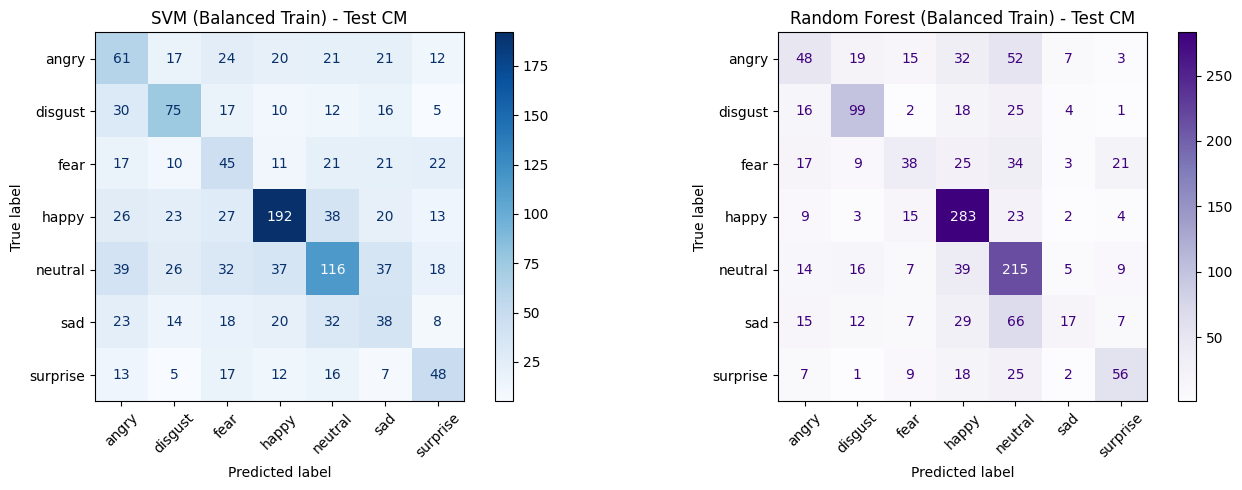

In [55]:
# -------------------------------
# DAY 5 RESULT TABLE + CONFUSION MATRICES
# -------------------------------
day5_comparison_df = pd.DataFrame([
    {"model": "SVM (baseline)", "test_accuracy": test_acc, "test_macro_f1": test_f1_macro},
    {"model": "SVM (balanced train)", "test_accuracy": test_acc_svm_bal, "test_macro_f1": test_f1_svm_bal},
    {"model": "RandomForest (baseline)", "test_accuracy": test_acc_rf, "test_macro_f1": test_f1_rf},
    {"model": "RandomForest (balanced train)", "test_accuracy": test_acc_rf_bal, "test_macro_f1": test_f1_rf_bal},
])

display(day5_comparison_df)

best_day5 = day5_comparison_df.sort_values("test_macro_f1", ascending=False).iloc[0]
print("Best model after Day 5 (by macro-F1):", best_day5["model"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_svm_bal,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("SVM (Balanced Train) - Test CM")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_rf_bal,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Purples",
    ax=axes[1]
)
axes[1].set_title("Random Forest (Balanced Train) - Test CM")

plt.tight_layout()
plt.show()

## Day 5 Checklist

- [ ] Run Day 3 and Day 4 first
- [ ] Apply random oversampling on training data only
- [ ] Retrain SVM and Random Forest on balanced training set
- [ ] Compare baseline vs balanced metrics on the same test set
- [ ] Save Day 5 comparison table and confusion matrix figure

### Day 5 Deliverables for Report
1. Imbalance strategy used: random oversampling (train split only)
2. Before vs after metrics for SVM and Random Forest
3. Which model improved most in macro-F1
4. Final selected model for deployment/UI demo

## Day 6: Final Evaluation and Report-Ready Results

Day 6 objective:
1. Consolidate all experiment results (Day 3, Day 4, Day 5)
2. Select the best model using macro-F1
3. Analyze per-class performance (precision/recall/F1)
4. Export final tables for proposal report and presentation

In [56]:
# -------------------------------
# CHECK REQUIRED RESULTS
# -------------------------------
required_day6_vars = [
    "y_test", "label_encoder",
    "test_acc", "test_f1_macro",
    "test_acc_rf", "test_f1_rf",
    "test_acc_svm_bal", "test_f1_svm_bal",
    "test_acc_rf_bal", "test_f1_rf_bal",
    "y_test_pred", "y_test_pred_rf", "y_test_pred_svm_bal", "y_test_pred_rf_bal"
]
missing_day6 = [v for v in required_day6_vars if v not in globals()]
if missing_day6:
    raise ValueError(
        "Missing variables for Day 6: " + ", ".join(missing_day6) +
        "\nRun Day 3, Day 4, and Day 5 first."
    )

print("All required Day 6 inputs found.")

All required Day 6 inputs found.


,model,test_accuracy,test_macro_f1
0,Random Forest (balanced train),0.538845,0.461897
1,Random Forest (baseline),0.505346,0.404348
2,SVM (balanced train),0.409836,0.384106
3,SVM (baseline),0.414113,0.381031


<Figure size 1000x500 with 0 Axes>

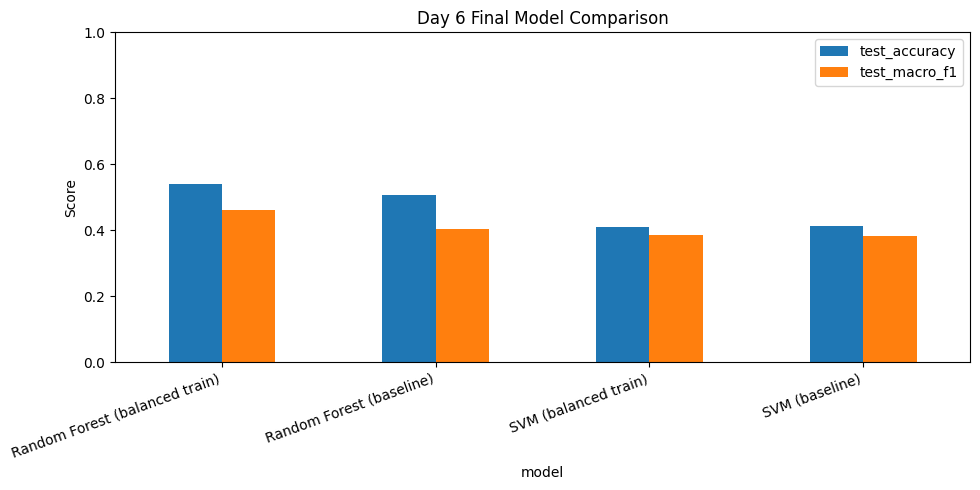

Best model by macro-F1: Random Forest (balanced train)


In [57]:
# -------------------------------
# CONSOLIDATED MODEL COMPARISON
# -------------------------------
all_results_df = pd.DataFrame([
    {"model": "SVM (baseline)", "test_accuracy": test_acc, "test_macro_f1": test_f1_macro},
    {"model": "Random Forest (baseline)", "test_accuracy": test_acc_rf, "test_macro_f1": test_f1_rf},
    {"model": "SVM (balanced train)", "test_accuracy": test_acc_svm_bal, "test_macro_f1": test_f1_svm_bal},
    {"model": "Random Forest (balanced train)", "test_accuracy": test_acc_rf_bal, "test_macro_f1": test_f1_rf_bal},
]).sort_values(by="test_macro_f1", ascending=False).reset_index(drop=True)

display(all_results_df)

plt.figure(figsize=(10, 5))
plot_df = all_results_df.set_index("model")[["test_accuracy", "test_macro_f1"]]
plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Day 6 Final Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

best_model_name = all_results_df.iloc[0]["model"]
print("Best model by macro-F1:", best_model_name)

,emotion_class,precision,recall,f1-score,support
0,angry,0.380952,0.272727,0.317881,176.0
1,disgust,0.622642,0.600000,0.611111,165.0
2,fear,0.408602,0.258503,0.316667,147.0
3,happy,0.637387,0.834808,0.722861,339.0
4,neutral,0.488636,0.704918,0.577181,305.0
5,sad,0.425000,0.111111,0.176166,153.0
6,surprise,0.554455,0.474576,0.511416,118.0


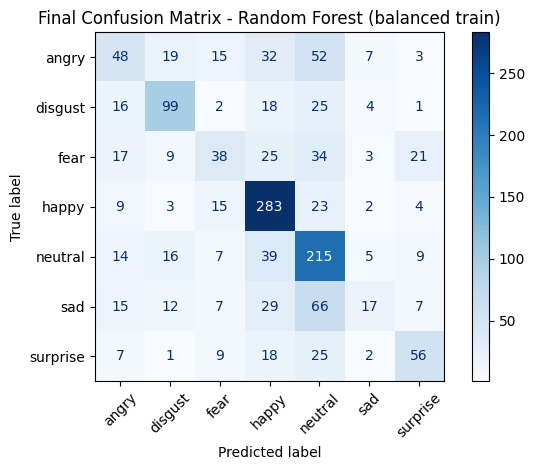

In [58]:
# -------------------------------
# PER-CLASS METRICS FOR BEST MODEL
# -------------------------------
pred_map = {
    "SVM (baseline)": y_test_pred,
    "Random Forest (baseline)": y_test_pred_rf,
    "SVM (balanced train)": y_test_pred_svm_bal,
    "Random Forest (balanced train)": y_test_pred_rf_bal,
}

best_pred = pred_map[best_model_name]
best_report = classification_report(
    y_test,
    best_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

per_class_df = pd.DataFrame(best_report).T
per_class_df = per_class_df.iloc[:-3].reset_index().rename(columns={"index": "emotion_class"})

display(per_class_df[["emotion_class", "precision", "recall", "f1-score", "support"]])

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)
plt.title(f"Final Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

In [59]:
# -------------------------------
# EXPORT REPORT TABLES
# -------------------------------
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

all_results_path = REPORTS_DIR / "day6_all_model_results.csv"
per_class_path = REPORTS_DIR / "day6_best_model_per_class_metrics.csv"

all_results_df.to_csv(all_results_path, index=False)
per_class_df.to_csv(per_class_path, index=False)

print("Saved:", all_results_path.resolve())
print("Saved:", per_class_path.resolve())

Saved: /reports/day6_all_model_results.csv
Saved: /reports/day6_best_model_per_class_metrics.csv


### Report-Ready Conclusion (Template)

Use this in your final report after running Day 6:

- We compared two proposal algorithms: **SVM** and **Random Forest**.
- We evaluated both baseline training and class-imbalance handling (random oversampling on training data only).
- The final selected model by **test macro-F1** is: **`<best_model_name>`**.
- This model achieved better balanced performance across emotion classes, as shown in the final confusion matrix and per-class metrics table.
- Therefore, `<best_model_name>` is recommended for the project demo UI and final deployment.

## Day 6 Checklist

- [ ] Run Day 3, Day 4, and Day 5 first
- [ ] Generate final comparison chart and table
- [ ] Identify best model by macro-F1
- [ ] Save final confusion matrix of best model
- [ ] Export CSV result tables to `../reports/`
- [ ] Copy Day 6 conclusion text into report/slides

### Day 6 Deliverables for Report
1. Final comparison table of all experiments
2. Best model selection criterion (macro-F1)
3. Per-class metrics table for selected model
4. Final confusion matrix and summary conclusion

## Day 7: Demo UI + Final Packaging

Day 7 objective:
1. Export the selected best model from Day 6
2. Save metadata needed for inference (class labels, input size)
3. Provide a minimal Streamlit UI for image upload and emotion prediction
4. Prepare final demo instructions for presentation day

In [68]:
# -------------------------------
# EXPORT BEST MODEL FOR UI
# -------------------------------
import json
import joblib

if "best_model_name" not in globals():
    raise ValueError("Run Day 6 first to compute best_model_name.")

model_map = {
    "SVM (baseline)": svm_model,
    "Random Forest (baseline)": rf_model,
    "SVM (balanced train)": svm_bal_model,
    "Random Forest (balanced train)": rf_bal_model,
}

best_model_obj = model_map[best_model_name]

ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

model_path = ARTIFACTS_DIR / "best_emotion_model.joblib"
metadata_path = ARTIFACTS_DIR / "model_metadata.json"

joblib.dump(best_model_obj, model_path)

metadata = {
    "best_model_name": best_model_name,
    "target_size": list(TARGET_SIZE),
    "labels": label_encoder.classes_.tolist(),
    "feature_type": "HOG",
    "face_detection": "HaarCascade",
    "engagement_mapping": {
        "Engaged": ["happy", "surprise"],
        "Neutral": ["neutral"],
        "Not Engaged": ["angry", "disgust", "fear", "sad"]
    }
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved model:", model_path.resolve())
print("Saved metadata:", metadata_path.resolve())

Saved model: /artifacts/best_emotion_model.joblib
Saved metadata: /artifacts/model_metadata.json


In [69]:
from google.colab import files
files.download('/artifacts/model_metadata.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Day 7 Notebook Output

After running the export cell, you should have:
- `../artifacts/best_emotion_model.joblib`
- `../artifacts/model_metadata.json`

These files are used directly by the Streamlit app (`app.py`).

In [ ]:
files.download('/artifacts/best_emotion_model.joblib')